# Screener diario — Acciones US (S&P 500 + Nasdaq)

Detecta candidatas a COMPRA con buena tendencia, fuerza relativa y fundamentales sólidos. Veta cualquier candidata que tenga señales de salida activas (regla dura).

**Cómo usar este notebook:**
1. Run all (Ctrl+Shift+Enter en cada celda o Run All)
2. Lee la sección de tarjetas de COMPRA
3. Lee la sección de SALIDA / EVITAR si tienes posiciones
4. Decisión final tuya

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 60)

from screener.pipeline import run_pipeline
from screener.spanish_cards import render_top_buys, render_top_observar, render_exit_watch, summary_table
from data.config_loader import load_config

In [2]:
# === CONFIGURACIÓN DE LA EJECUCIÓN ===
# Modos disponibles:
#   - "smoke":   10 tickers conocidos. Para probar el sistema (~30s).
#   - "full":    Universo completo S&P500 + Nasdaq100 (~600 tickers, ~10 min primera vez, segs con cache).
#   - "custom":  Lista que defines abajo en CUSTOM_TICKERS.
MODE = "full"

# Modo de fundamentales:
#   - "auto":          Usa FMP si tienes API key, sino yfinance.
#   - "yfinance_only": Solo yfinance (rápido, ilimitado).
#   - "fmp":           Solo FMP. Requiere API key (free tier: 250 req/día).
FUND_MODE = "yfinance_only"

CUSTOM_TICKERS = ["NVDA", "AAPL", "MSFT", "AMD", "INTC", "MU", "STX", "WDC", "LRCX", "SNDK"]

SMOKE_TICKERS = ["NVDA", "SMCI", "AAPL", "MSFT", "INTC", "PLTR", "TSLA", "COIN", "AMD", "GOOG"]


In [3]:
# Ejecutar el pipeline
if MODE == "smoke":
    tickers = SMOKE_TICKERS
elif MODE == "custom":
    tickers = CUSTOM_TICKERS
else:
    tickers = None  # universo completo

df = run_pipeline(tickers=tickers, fund_mode=FUND_MODE, verbose=True)
print(f"\nProcesadas {len(df)} empresas.\n")
print("Distribución de señales:")
print(df['signal'].value_counts())

Universo: 516 tickers


Screening: 100%|█████████████████████████████████████████████████████████████████████████████████████████| 516/516 [00:42<00:00, 12.01it/s]


Procesadas 515 empresas.

Distribución de señales:
signal
EVITAR        341
SALIDA        130
OBSERVAR       42
COMPRA          1
INELIGIBLE      1
Name: count, dtype: int64


## Tabla resumen

In [4]:
summary_table(df)

,ticker,signal,sector,fund_composite,rs_rating,qv_score,fi_score,theme_score,f_score,trend_template,breakout,exit_active
0,LRCX,COMPRA,Technology,64.396641,97.281553,44.186047,40.0,88.888889,0,True,True,False
1,FICO,EVITAR,Technology,84.241602,4.466019,93.798450,40.0,88.888889,0,False,False,True
2,CPAY,EVITAR,Technology,83.776486,40.388350,92.635659,40.0,88.888889,0,False,False,True
3,ADSK,EVITAR,Technology,80.664083,19.805825,93.604651,20.0,88.888889,0,False,False,True
4,EQT,EVITAR,Energy,80.571059,52.038835,96.705426,60.0,55.555556,0,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
510,ALB,SALIDA,Basic Materials,23.341085,96.893204,2.519380,-20.0,33.333333,0,True,False,True
511,SBUX,SALIDA,Consumer Cyclical,22.036176,76.310680,6.201550,-20.0,22.222222,0,True,False,True
512,LYB,SALIDA,Basic Materials,21.779070,89.320388,7.364341,-40.0,33.333333,0,True,False,True
513,UNH,SALIDA,Healthcare,21.202842,79.611650,14.534884,-20.0,5.555556,0,False,False,True


## 🟢 Top candidatas COMPRA hoy

In [5]:
cfg = load_config()
n_buy = cfg.get('output', {}).get('top_n_buy', 10)
print(render_top_buys(df, n=n_buy))


=== TOP 1 CANDIDATAS COMPRA ===

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 LRCX  ·  Technology  ·  🟢 COMPRA
 Precio: 297.17   |   Rango 52s: 72.63 – 297.17
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Veredicto: Buen punto de entrada hoy. Cumple criterios de tendencia, fuerza y momento, y no hay señales de aviso.

 📊 Puntuaciones (0 = malo, 100 = excelente):
   Calidad+Valor    [█████████░░░░░░░░░░░] 44/100
   Inflexión        [██████████████░░░░░░] 70/100
   Viento sectorial [██████████████████░░] 89/100
   Composite total  [█████████████░░░░░░░] 64/100
   Fuerza vs S&P    [███████████████████░] 97/100
   Piotroski        0/9

 ✅ Lo que tiene a favor:
   · Patrón de tendencia alcista (Stage 2)
   · No extendida (24% sobre SMA50)
   · Fuerza relativa alta (RS 97/100)
   · Línea de fuerza relativa en máximos
   · Breakout sobre pivot con volumen 1.4× lo normal

 🌱 Señales fundamentales:
   · Revisiones de analistas al alza
   · Beat consistente últimos 2 trimestres



## ⚪ Top OBSERVAR — watchlist próximos disparos

Empresas de calidad con buena fuerza relativa que aún no cumplen TODOS los criterios de entrada (ej. esperando pullback si están extendidas, o esperando breakout con volumen). Son las primeras candidatas a vigilar día a día.

In [6]:
print(render_top_observar(df, n=15))


=== TOP 15 OBSERVAR (watchlist próximos disparos) ===

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 STX  ·  Technology  ·  ⚪ OBSERVAR
 Precio: 786.42   |   Rango 52s: 92.71 – 786.42
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Veredicto: Empresa de calidad pero sin disparador de entrada hoy. Mantener en lista de seguimiento.

 📊 Puntuaciones (0 = malo, 100 = excelente):
   Calidad+Valor    [████████████████████] 100/100
   Inflexión        [████████████████░░░░] 80/100
   Viento sectorial [██████████████████░░] 89/100
   Composite total  [██████████████████░░] 90/100
   Fuerza vs S&P    [████████████████████] 99/100
   Piotroski        0/9

 ✅ Lo que tiene a favor:
   · Patrón de tendencia alcista (Stage 2)
   · Fuerza relativa alta (RS 99/100)
   · Línea de fuerza relativa en máximos

 🌱 Señales fundamentales:
   · Revisiones de analistas al alza
   · Beat consistente últimos 2 trimestres
   · Margen bruto en expansión los últimos 4 trimestres

 ⚠️ Lo que falla para entra

## 🚪 Vigilancia de salida (SALIDA / EVITAR)

Empresas con alguna señal de aviso activa. Si tienes posición en alguna, revisa los motivos.

In [7]:
from screener.spanish_cards import render_card
TICKER = "LRCX"  # Cambia por el ticker que quieras inspeccionar
row = df[df['ticker'] == TICKER]
if row.empty:
    print(f"{TICKER} no está en los resultados de hoy. Cambia MODE y vuelve a ejecutar.")
else:
    print(render_card(row.iloc[0]))

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 LRCX  ·  Technology  ·  🟢 COMPRA
 Precio: 297.17   |   Rango 52s: 72.63 – 297.17
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Veredicto: Buen punto de entrada hoy. Cumple criterios de tendencia, fuerza y momento, y no hay señales de aviso.

 📊 Puntuaciones (0 = malo, 100 = excelente):
   Calidad+Valor    [█████████░░░░░░░░░░░] 44/100
   Inflexión        [██████████████░░░░░░] 70/100
   Viento sectorial [██████████████████░░] 89/100
   Composite total  [█████████████░░░░░░░] 64/100
   Fuerza vs S&P    [███████████████████░] 97/100
   Piotroski        0/9

 ✅ Lo que tiene a favor:
   · Patrón de tendencia alcista (Stage 2)
   · No extendida (24% sobre SMA50)
   · Fuerza relativa alta (RS 97/100)
   · Línea de fuerza relativa en máximos
   · Breakout sobre pivot con volumen 1.4× lo normal

 🌱 Señales fundamentales:
   · Revisiones de analistas al alza
   · Beat consistente últimos 2 trimestres


# Chart anotado del ticker seleccionado (candlestick + SMAs + pivot breakout + volumen)
import mplfinance as mpf
import pandas as pd
from data.fetch_prices import get_prices
from technicals.indicators import sma, atr
from technicals.breakout import detect_breakout

prices = get_prices(TICKER)
tail = prices.tail(252).copy()
tail.index = pd.to_datetime(tail.index)

# SMAs
sma50 = sma(prices['close'], 50).reindex(tail.index)
sma150 = sma(prices['close'], 150).reindex(tail.index)
sma200 = sma(prices['close'], 200).reindex(tail.index)

# Pivot resistance del último breakout (highest high de los 50 días previos al cierre)
bk = detect_breakout(prices)
pivot = bk.get('pivot') if bk else None

# Chandelier stop (3 ATR bajo high22)
high22 = prices['high'].rolling(22, min_periods=22).max()
chand = (high22 - 3 * atr(prices, 22)).reindex(tail.index)

addplots = [
    mpf.make_addplot(sma50, color='royalblue', width=1.0, label='SMA50'),
    mpf.make_addplot(sma150, color='orange', width=1.0, label='SMA150'),
    mpf.make_addplot(sma200, color='red', width=1.0, label='SMA200'),
    mpf.make_addplot(chand, color='gray', width=0.8, linestyle='--', label='Stop ATR(3x)'),
]
hlines = dict(hlines=[pivot], colors=['green'], linestyle='--', linewidths=1) if pivot else {}

mpf.plot(
    tail, type='candle', style='yahoo', volume=True, figsize=(13, 8),
    title=f'{TICKER} — 12 meses' + (f'  ·  pivot {pivot:.2f}' if pivot else ''),
    addplot=addplots, hlines=hlines or None, tight_layout=True,
)

In [8]:
from screener.spanish_cards import render_card
TICKER = "NVDA"
row = df[df['ticker'] == TICKER]
if row.empty:
    print(f"{TICKER} no está en los resultados de hoy. Cambia MODE y vuelve a ejecutar.")
else:
    print(render_card(row.iloc[0]))

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 NVDA  ·  Technology  ·  ⚪ OBSERVAR
 Precio: 207.83   |   Rango 52s: 113.51 – 216.61
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Veredicto: Empresa de calidad pero sin disparador de entrada hoy. Mantener en lista de seguimiento.

 📊 Puntuaciones (0 = malo, 100 = excelente):
   Calidad+Valor    [███████████████░░░░░] 75/100
   Inflexión        [██████████████░░░░░░] 70/100
   Viento sectorial [██████████████████░░] 89/100
   Composite total  [███████████████░░░░░] 77/100
   Fuerza vs S&P    [████████████████░░░░] 81/100
   Piotroski        5/9

 ✅ Lo que tiene a favor:
   · Patrón de tendencia alcista (Stage 2)
   · No extendida (11% sobre SMA50)
   · Fuerza relativa alta (RS 81/100)

 🌱 Señales fundamentales:
   · Revisiones de analistas al alza
   · Margen bruto en expansión los últimos 4 trimestres

 ⚠️ Lo que falla para entrar:
   · Sin breakout reciente sobre resistencia


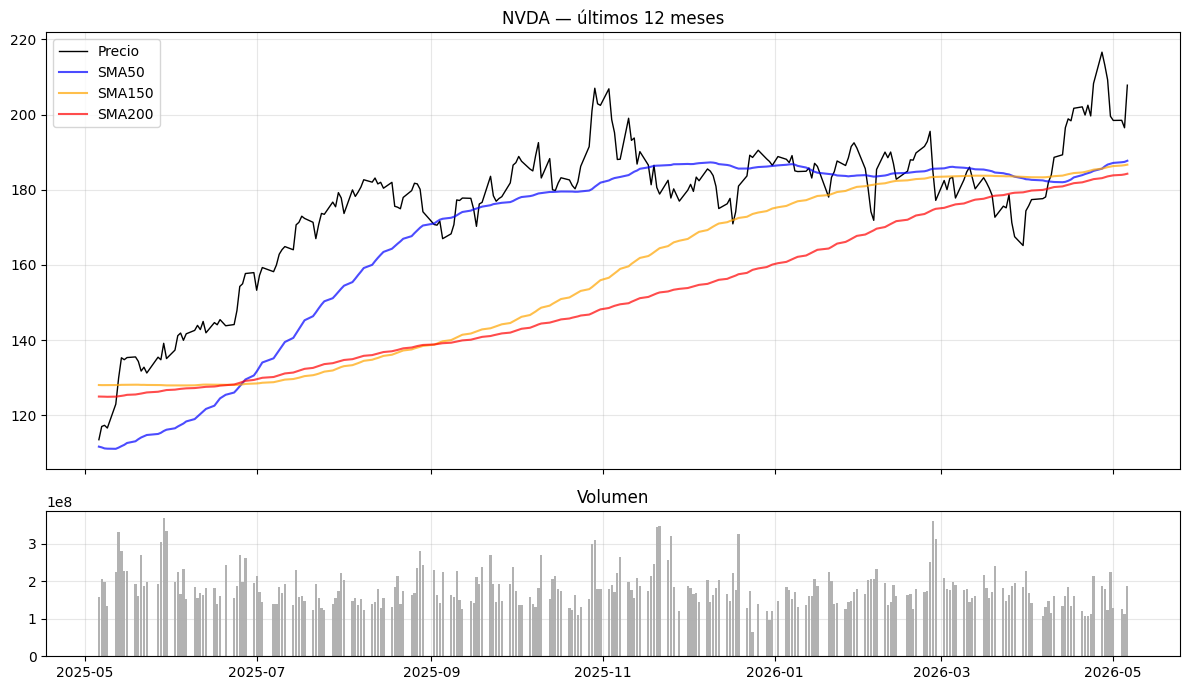

In [9]:
# Chart anotado del ticker seleccionado
from data.fetch_prices import get_prices
from technicals.indicators import sma
import matplotlib.pyplot as plt

prices = get_prices(TICKER)
tail = prices.tail(252)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
ax1.plot(tail.index, tail['close'], label='Precio', color='black', linewidth=1)
ax1.plot(tail.index, sma(prices['close'], 50).tail(252), label='SMA50', color='blue', alpha=0.7)
ax1.plot(tail.index, sma(prices['close'], 150).tail(252), label='SMA150', color='orange', alpha=0.7)
ax1.plot(tail.index, sma(prices['close'], 200).tail(252), label='SMA200', color='red', alpha=0.7)
ax1.set_title(f'{TICKER} — últimos 12 meses')
ax1.legend()
ax1.grid(alpha=0.3)
ax2.bar(tail.index, tail['volume'], color='gray', alpha=0.6)
ax2.set_title('Volumen')
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()